<a href="https://colab.research.google.com/github/wetherc/data-3000/blob/SP25/labs/06b_convolutional-networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flower Species Classification

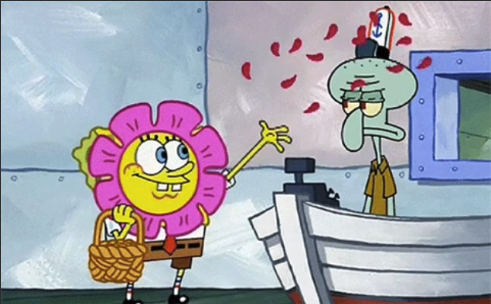

In this lab, we will be training a convolutional neural network to correctly classify flowers into one of 5 different species. We'll be using all the same concepts that we discussed in class on Tuesday, as well as introducing several new ones throughout the lab here

## Setup

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

### Download and explore the dataset

This tutorial uses a dataset of about 3,700 photos of flowers. The dataset contains five sub-directories, one per class:

```
flower_photo/
  daisy/
  dandelion/
  roses/
  sunflowers/
  tulips/
```

In [ ]:
!wget --no-check-certificate \
    https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz \
    -O /tmp/flowers.tgz

--2025-03-25 20:32:12--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.12.207, 172.217.194.207, 172.253.118.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.12.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘/tmp/flowers.tgz’

/tmp/flowers.tgz    100%[===================>] 218.21M  22.1MB/s    in 11s     

2025-03-25 20:32:24 (20.5 MB/s) - ‘/tmp/flowers.tgz’ saved [228813984/228813984]



After downloading our data, we will need to unzip it (or untar it in this case). After this, we can take a look at the number of classes represented for each flower in our dataset

In [ ]:
import tarfile
import os

tar = tarfile.open('/tmp/flowers.tgz', 'r:gz')
tar.extractall('/tmp')
tar.close()

base_dir = '/tmp/flower_photos'

classes = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

# Directories with our training pictures
train_dirs = dict([(flower, os.path.join(base_dir, flower)) for flower in classes])
train_dirs

{'daisy': '/tmp/flower_photos/daisy',
 'dandelion': '/tmp/flower_photos/dandelion',
 'roses': '/tmp/flower_photos/roses',
 'sunflowers': '/tmp/flower_photos/sunflowers',
 'tulips': '/tmp/flower_photos/tulips'}

In [ ]:
for flower, path in train_dirs.items():
    print(f'total training {flower} images:', len(os.listdir(path)))

total training daisy images: 633
total training dandelion images: 898
total training roses images: 641
total training sunflowers images: 699
total training tulips images: 799


## Ingest our image data

In the example from Tuesday, our datasets were already split into dedicated training and validatino subfolders. Because these data are not, we will use a slightly different method for loading them in a way that Tensorflow is able to understand. Notably, here we are calling the `image_dataset_from_directory()` function and returning a tuple of training and validation datasets.

For full documentation on this function, refer to the [Tensorflow Documentation](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory)

In [ ]:
import tensorflow as tf

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
  base_dir,
  validation_split=0.2,
  subset="both",
  seed=123,
  image_size=(180, 180),
  batch_size=20)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


Although we see in the output above that Tensorflow found 5 unique classes, we can verify what the discovered class labels are:

In [ ]:
class_names = train_ds.class_names
class_names

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

Finally, we can display a handful of images to get a sense for what we'll be trying to correctly classify:

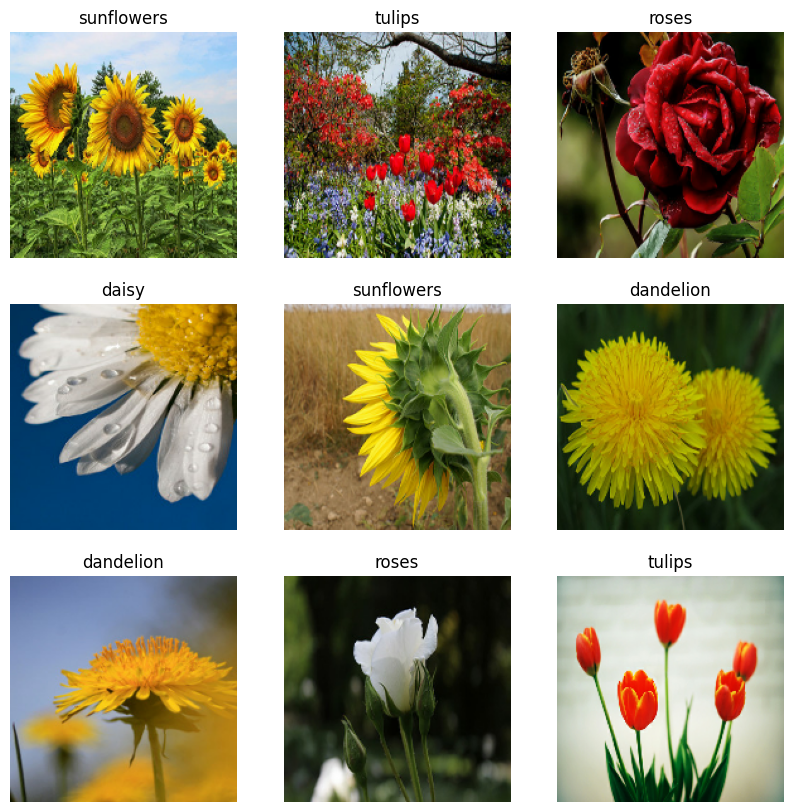

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

## Train a CNN

For this exercise, you should train a convolutional neural network using the concepts discussed in class on Tuesday. Specifically, you should fit a model that:

- Contains 2 or more convolutional modules
- Contains at least one fully-connected dense layer
- Is able to predict 5 separate flower species

To assist with this, I've provided some starter code that you can build upon as you construct the full model architecture.

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras import Model

# Our input feature map is 180x180x3:
# 180x180 for the image pixels, and 3 for
# the three color channels: R, G, and B
img_input = layers.Input(shape=(180, 180, 3))

# We will rescale our inputs within the model graph. This
# is a departure from what we did in class Tuesday ---
# because we aren't using the ImageDataGenerator,
# we're not able to utilize many of the same built-in
# image processing features and need to implement them
# within the model graph instead.
rescaled_input = layers.Rescaling(1./255)(img_input)

########################################
# Your model code should go here!
########################################


# Create output layer with a shape equal to the number
# of classes we're trying to predict. We will also use
# a softmax activation function rather than the typical
# sigmoid. The difference here being that a sigmoid function
# will produce discrete probabilities for each possible
# class: that is, it will make independent predictions
# for tulip, for daisy, and so on. These probabilities
# then can sum up to greater than 100%. In contrast, a
# softmax activation will make proportional predictions
# and the sum of all predicted probabilities across
# classes will sum up to 1.
output = layers.Dense(len(class_names), activation="softmax")(x)

# Create model:
# input = input feature map
# output = input feature map + stacked convolution/maxpooling layers + fully
# connected layer + sigmoid output layer
model = Model(img_input, output)

As you get ready to compile your model, you should use the `RMSProp` optimizer and the `SparseCategoricalCrossentropy` loss function. These are imported below for your convenience.

We generally use categorical crossentropy (without diving into the math of why) in cases where we have a multiclass classification task, versus binary crossentropy when we're making only a single binary classification.

In [ ]:
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.losses import SparseCategoricalCrossentropy

### Model Evaluation

How does your model perform? Does it overfit?

# Building a Better Classifier

Chances are, we've just built a model that does a really good job at memorizing flowers it's already seen, and only an okay job at IDing new flower photos.

This is a common occurrence when we're training models, and there are a handful of ways we can try and mitigate this during training

## Dropout Layers

A dropout layer represents a step in our network where we just zero out some proportion of the neurons in that layer and pretend like they totally don't exist. This tends to have the effect of forcing our model to do a slightly better job of learning latent features that actually generalize well, and to minimize the relative weighting of features that just happen to jive well with data that it's memorized.

In Tensorflow, we use a Dropout layer to do this:

```
from tensorflow.keras.layers import Dropout

dropout_layer = Dropout(0.2)(prior_layer)
```

This layer takes a single parameter, the proportion of neurons in the layer that we want to randomly ignore on each training pass. It's typical to set a value here somewhere between 20% and 50%, although the exact proportion will depend on the specifics of your use case and what just happens to work well in practice

## Image Augmentation

We can also add augmentations to our training images as part of our model graph. By doing things like applying crops, rotation, skew, shear, and so forth, we're able to increase the effective size of our training dataset.

Just like most other things in Tensorflow, there are layers for that! Tensorflow provides some [built-in options for easy data augmentation](https://www.tensorflow.org/tutorials/images/data_augmentation) that we can take advantage of here. There are also a number of `tf.image` methods that we can alternately use (Ref. [Module: tf.image](https://www.tensorflow.org/api_docs/python/tf/image)).

For example, to horizontally flip our images, and to rotate and zoom them, we can define these transformations in the same way we would any other layer in our model:

```
flipped_input = layers.RandomFlip(
    "horizontal",
    input_shape=(180, 180, 3)
)(img_input)
rotated_input = layers.RandomRotation(0.1)(flipped_input)
zoomed_input = layers.RandomZoom(0.1)(rotated_input)
```

## Applying the Concepts

For this exercise, redefine your original model architecture so that it follows the following structure:

- Input layer
- Several image augmentation layers of your choosing. [Valid options include](https://www.tensorflow.org/api_docs/python/tf/keras/layers/RandomBrightness):
  - RandomBrightness
  - RandomContrast
  - RandomCrop
  - RandomFlip
  - RandomHeight
  - RandomRotation
  - RandomTranslation
  - RandomWidth
  - RandomZoom
- The convolutional modules you defined in the prior part of the lab
- A dropout layer
- A flatten layer + your dense network both defined in the prior part of the lab

As before, you should evaluate your model's accuracy